In [1]:
# %%
import os, json, math, time, inspect, random
from pathlib import Path
from typing import Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Set publication‑style defaults
plt.rcParams.update({
    'font.sans-serif': 'Helvetica',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.linewidth': 0.8,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'image.cmap': 'viridis'
})

# Neuralop imports
try:
    from neuralop.layers.gno_block import GNOBlock
except Exception as e:
    raise RuntimeError("GNOBlock not available. Activate neuralop environment.") from e
try:
    from neuralop.models import FNO
except Exception:
    FNO = None  # Field model will need it, error later if missing

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Device: cuda


In [2]:
# %%
def as_list(arr):
    if arr is None: return []
    if hasattr(arr, 'tolist'): arr = arr.tolist()
    return [str(x) for x in arr]

def load_contexts(npz, n):
    for key in ('pair_contexts', 'frame_contexts'):
        if key in npz:
            raw = npz[key]
            out = []
            for item in raw.tolist():
                if isinstance(item, dict): out.append(item)
                else: out.append({})
            return out
    return [{} for _ in range(n)]

def get_pair_ranges(npz):
    for key in ('pair_ranges', 'frame_ranges'):
        if key in npz: return npz[key]
    raise KeyError("No pair_ranges/frame_ranges in dataset")

def stat(npz, key, size=None, fill=0.0):
    if key in npz: return np.asarray(npz[key], dtype=np.float32).reshape(-1)
    if size is None: raise KeyError(key)
    return np.full((size,), fill, dtype=np.float32)

def normalize_xyz(xyz, cmin, cspan):
    return np.clip((xyz - cmin) / np.maximum(cspan, 1e-8), 0.0, 1.0).astype(np.float32)

def context_global_params(ctx):
    aoa = float(ctx.get('angle_of_attack', ctx.get('aoa', 0.0))) / 45.0
    uinf = float(ctx.get('freestream_magnitude', ctx.get('Uinf', 10.0))) / 10.0
    phase = float(ctx.get('phase', 0.0))
    return np.asarray([aoa, uinf, phase], dtype=np.float32)

def sample_indices(n, cap, seed):
    if cap is None or cap <= 0 or n <= cap: return np.arange(n)
    rng = np.random.default_rng(int(seed))
    return np.sort(rng.choice(n, size=int(cap), replace=False)).astype(np.int64)

# GNO block factory (identical to training)
def make_gnoblock(in_channels, out_channels, radius, reduction='mean'):
    sig = inspect.signature(GNOBlock)
    kwargs = {}
    for name in sig.parameters:
        if name in {'in_channels','in_chan','in_features'}: kwargs[name] = in_channels
        elif name in {'out_channels','out_chan','out_features'}: kwargs[name] = out_channels
        elif name in {'radius','radius_cutoff'}: kwargs[name] = radius
        elif name == 'coord_dim': kwargs[name] = 3
        elif name == 'reduction': kwargs[name] = reduction
        elif name == 'pos_embedding_type': kwargs[name] = 'transformer'
        elif name == 'channel_mlp_layers': kwargs[name] = [in_channels, out_channels, out_channels]
        elif name == 'use_open3d_neighbor_search': kwargs[name] = False
        elif name == 'use_torch_scatter_reduce': kwargs[name] = False
    try: return GNOBlock(**kwargs)
    except TypeError: return GNOBlock(in_channels=in_channels, out_channels=out_channels, coord_dim=3, radius=radius)

def call_gno(block, x, y, f_y):
    try: return block(y=x, x=y, f_y=f_y)
    except TypeError: return block(x=y, y=x, f_y=f_y)

def rel_l2(pred, true, eps=1e-12):
    pred = torch.nan_to_num(pred); true = torch.nan_to_num(true)
    num = torch.linalg.vector_norm((pred - true).reshape(pred.shape[0], -1), dim=1)
    den = torch.linalg.vector_norm(true.reshape(true.shape[0], -1), dim=1).clamp_min(eps)
    return (num / den).mean()

In [3]:
# %%
# ----- Particle Evolution GNO -----
class ParticleEvolutionGNO(nn.Module):
    def __init__(self, in_channels, out_channels, hidden=128, layers=4, radius=0.30, global_dim=3):
        super().__init__()
        self.lift = nn.Sequential(nn.Linear(in_channels, hidden), nn.GELU(), nn.Linear(hidden, hidden))
        self.global_condition_mlp = nn.Sequential(nn.Linear(global_dim, hidden), nn.GELU(), nn.Linear(hidden, hidden))
        self.blocks = nn.ModuleList([make_gnoblock(hidden, hidden, radius) for _ in range(layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(layers)])
        self.particle_skip_proj = nn.Linear(hidden, hidden)
        self.delta_fusion = nn.Sequential(nn.Linear(2*hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden))
        self.delta_head = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, out_channels))
    def forward(self, input_geom, x, global_params):
        if input_geom.ndim == 2: input_geom = input_geom.unsqueeze(0); x = x.unsqueeze(0); global_params = global_params.unsqueeze(0)
        h0 = self.lift(x)
        h = h0 + self.global_condition_mlp(global_params).unsqueeze(1)
        outs = []
        for b in range(h.shape[0]):
            hb = h[b]; coords = input_geom[b]
            for blk, norm in zip(self.blocks, self.norms):
                upd = call_gno(blk, x=coords, y=coords, f_y=hb)
                if upd.ndim == 3: upd = upd.squeeze(0)
                hb = norm(hb + upd)
            outs.append(hb)
        h = torch.stack(outs, dim=0)
        h = self.delta_fusion(torch.cat([h, self.particle_skip_proj(h0)], dim=-1))
        return self.delta_head(h)

# ----- Field Reconstruction GINO -----
def positional_encoding(x, num_freqs=4):
    freqs = (2.0 ** torch.arange(num_freqs, device=x.device, dtype=x.dtype)) * math.pi
    xb = x.unsqueeze(-2) * freqs.view(1,1,-1,1)
    return torch.cat([x, torch.sin(xb).flatten(-2), torch.cos(xb).flatten(-2)], dim=-1)

def make_latent_grid(res, device):
    lin = torch.linspace(0, 1, res, device=device)
    zz, yy, xx = torch.meshgrid(lin, lin, lin, indexing='ij')
    return torch.stack([xx, yy, zz], dim=-1).reshape(-1, 3)

class FieldReconstructionGINO(nn.Module):
    def __init__(self, in_channels, out_channels=3, hidden=128, latent_res=24,
                 fno_layers=6, fno_modes=6, radius=0.15, global_dim=3):
        super().__init__()
        self.latent_res = latent_res; self.hidden = hidden
        self.lift = nn.Sequential(nn.Linear(in_channels, hidden), nn.GELU(), nn.Linear(hidden, hidden))
        self.encoder = make_gnoblock(hidden, hidden, radius)
        self.global_condition_mlp = nn.Sequential(nn.Linear(global_dim, hidden), nn.GELU(), nn.Linear(hidden, hidden))
        if FNO is None:
            raise RuntimeError("FNO not available. Install neuralop with FNO support.")
        self.fno = FNO(n_modes=(fno_modes,fno_modes,fno_modes), hidden_channels=hidden, in_channels=hidden, out_channels=hidden, n_layers=fno_layers)
        pe_dim = 3 + 2*4*3
        self.decoder = nn.Sequential(nn.Linear(hidden+pe_dim, hidden), nn.GELU(), nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, out_channels))
    def sample_grid(self, grid, queries):
        q = queries.clamp(0,1)*2 - 1
        q = q[..., [2,1,0]].view(q.shape[0], q.shape[1], 1,1,3)
        vals = F.grid_sample(grid, q, mode='bilinear', align_corners=True).squeeze(-1).squeeze(-1).transpose(1,2)
        return vals
    def forward(self, input_geom, x, output_queries, global_params):
        if input_geom.ndim == 2: input_geom = input_geom.unsqueeze(0); x = x.unsqueeze(0); output_queries = output_queries.unsqueeze(0); global_params = global_params.unsqueeze(0)
        base_grid = make_latent_grid(self.latent_res, input_geom.device)
        h = self.lift(x)
        latent_batches = []
        for b in range(h.shape[0]):
            lat = call_gno(self.encoder, x=input_geom[b], y=base_grid, f_y=h[b])
            if lat.ndim == 3: lat = lat.squeeze(0)
            latent_batches.append(lat)
        latent = torch.stack(latent_batches, dim=0)
        latent = latent + self.global_condition_mlp(global_params).unsqueeze(1)
        grid = latent.transpose(1,2).reshape(latent.shape[0], self.hidden, self.latent_res, self.latent_res, self.latent_res)
        grid = self.fno(grid)
        qfeat = self.sample_grid(grid, output_queries)
        return self.decoder(torch.cat([qfeat, positional_encoding(output_queries)], dim=-1))

In [4]:
# %%
# ---- Specify checkpoint paths ----
# Set these via environment or edit directly.
PARTICLE_CKPT = os.environ.get('PARTICLE_GNO_CKPT', 'GINO_GNO/result/particle_evolution_gno/particle_evolution_gno_best_model.pt')
FIELD_CKPT = os.environ.get('FIELD_GINO_CKPT', 'GINO_GNO/result/field_reconstruction_gino/field_reconstruction_gino_best_model.pt')
DATASET_PATH = os.environ.get('EVOLUTION_DATASET', 'processed_data/particle_evolution_dataset.npz')

# Decide which model to evaluate (default: particle if both exist, else field)

CKPT_PATH = Path(FIELD_CKPT)


# checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
cfg = checkpoint.get('cfg', checkpoint.get('config', {}))  # training notebooks saved 'cfg' or 'config'

# Detect model type
if 'field_mean' in checkpoint and 'field_target_names' in checkpoint:
    MODEL_TYPE = 'field'
    print("Detected FIELD RECONSTRUCTION model")
else:
    MODEL_TYPE = 'particle'
    print("Detected PARTICLE EVOLUTION model")

# Load dataset (same npz for both)
npz = np.load(DATASET_PATH, allow_pickle=True)
inputs_t = np.asarray(npz['inputs_t'], dtype=np.float32)
pair_ranges = get_pair_ranges(npz)
contexts = load_contexts(npz, len(pair_ranges))
feature_names_all = as_list(npz['feature_names'])

# Common normalization
coord_min = stat(npz, 'coord_min', 3, 0.0)
coord_span = stat(npz, 'coord_span', 3, 1.0)
in_mean_all = stat(npz, 'in_mean', inputs_t.shape[1], 0.0).reshape(-1)
in_std_all = np.maximum(stat(npz, 'in_std', inputs_t.shape[1], 1.0).reshape(-1), 1e-8)

# Splits
if 'train_pair_ids' in npz:
    train_ids = np.asarray(npz['train_pair_ids'], dtype=np.int64)
    val_ids   = np.asarray(npz['val_pair_ids'], dtype=np.int64)
    test_ids  = np.asarray(npz['test_pair_ids'], dtype=np.int64)
else:
    n = len(pair_ranges)
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(n)
    n_train, n_val = int(0.8*n), int(0.1*n)
    train_ids = perm[:n_train]; val_ids = perm[n_train:n_train+n_val]; test_ids = perm[n_train+n_val:]

print(f"Train pairs: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")

Detected FIELD RECONSTRUCTION model
Train pairs: 550, Val: 200, Test: 100


In [5]:
# %%
if MODEL_TYPE == 'particle':
    # Extract particle‑specific checkpoint data
    feature_names = as_list(checkpoint.get('feature_names', checkpoint.get('input_channels', [])))
    target_names = as_list(checkpoint['target_names'])
    out_channels = len(target_names)
    in_mean = stat(npz, 'in_mean', inputs_t.shape[1], 0.0).reshape(-1)
    in_std = np.maximum(stat(npz, 'in_std', inputs_t.shape[1], 1.0).reshape(-1), 1e-8)
    target_mean = checkpoint['target_mean']
    target_std = checkpoint['target_std']
    # Model args
    model = ParticleEvolutionGNO(
        in_channels=len(feature_names),
        out_channels=out_channels,
        hidden=cfg.get('hidden_channels', 128),
        layers=cfg.get('num_gno_layers', 4),
        radius=cfg.get('gno_radius', 0.3)
    ).to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    model.eval()
    # Build dataset / loader
    active_idx = np.asarray([feature_names_all.index(n) for n in feature_names], dtype=np.int64)
    coord_idx = np.asarray([feature_names_all.index(k) for k in ('x','y','z')], dtype=np.int64)
    class ParticleEvalDataset(Dataset):
        def __init__(self, ids):
            self.ids = np.asarray(ids, dtype=np.int64)
        def __len__(self): return len(self.ids)
        def __getitem__(self, i):
            pid = int(self.ids[i])
            start, end = int(pair_ranges[pid][3]), int(pair_ranges[pid][4])
            rows = inputs_t[start:end]
            coords = normalize_xyz(rows[:, coord_idx], coord_min, coord_span)
            x = (rows[:, active_idx] - in_mean[active_idx]) / in_std[active_idx]
            return {'input_geom': torch.from_numpy(coords), 'x': torch.from_numpy(x.astype(np.float32)),
                    'global_params': torch.from_numpy(context_global_params(contexts[pid]))}
    eval_ds = ParticleEvalDataset(test_ids)
else:  # field model
    feature_names = as_list(checkpoint.get('feature_names', checkpoint.get('input_channels', [])))
    field_target_names = as_list(checkpoint['field_target_names'])
    field_mean = checkpoint['field_mean']; field_std = checkpoint['field_std']
    active_idx = np.asarray([feature_names_all.index(n) for n in feature_names], dtype=np.int64)
    coord_idx = np.asarray([feature_names_all.index(k) for k in ('x','y','z')], dtype=np.int64)
    # Load field arrays
    for qk in ('query_coords','field_query_coords','output_queries'):
        if qk in npz: query_coords_all = np.asarray(npz[qk], dtype=np.float32); break
    for yk in ('targets_velocity_field_norm','targets_field_norm','y_field_norm'):
        if yk in npz: y_field_all = np.asarray(npz[yk], dtype=np.float32); break
    mask_all = np.asarray(npz['field_query_mask'], dtype=bool) if 'field_query_mask' in npz else np.ones(query_coords_all.shape[:-1], dtype=bool)

    model = FieldReconstructionGINO(
        in_channels=len(feature_names),
        out_channels=len(field_target_names),
        hidden=cfg.get('hidden_channels', 128),
        latent_res=cfg.get('latent_res', 24),
        fno_layers=cfg.get('fno_layers', 6),
        fno_modes=cfg.get('fno_modes', 6),
        radius=cfg.get('encoder_radius', 0.15)
    ).to(DEVICE)
    
    state_dict = checkpoint['model_state_dict']
    state_dict.pop("_metadata", None)          # discard auto‑added metadata
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    class FieldEvalDataset(Dataset):
        def __init__(self, ids):
            self.ids = np.asarray(ids, dtype=np.int64)
        def __len__(self): return len(self.ids)
        def __getitem__(self, i):
            pid = int(self.ids[i])
            start, end = int(pair_ranges[pid][3]), int(pair_ranges[pid][4])
            rows = inputs_t[start:end]
            coords = normalize_xyz(rows[:, coord_idx], coord_min, coord_span)
            x = (rows[:, active_idx] - in_mean_all[active_idx]) / in_std_all[active_idx]
            mask = mask_all[pid].astype(bool)
            valid = np.flatnonzero(mask)
            q = normalize_xyz(query_coords_all[pid, valid], coord_min, coord_span)
            y = y_field_all[pid, valid, :len(field_target_names)]
            return {'input_geom': torch.from_numpy(coords), 'x': torch.from_numpy(x.astype(np.float32)),
                    'output_queries': torch.from_numpy(q.astype(np.float32)),
                    'y_field': torch.from_numpy(y.astype(np.float32)),
                    'global_params': torch.from_numpy(context_global_params(contexts[pid]))}
    eval_ds = FieldEvalDataset(test_ids)

# Collate for batch_size=1
def collate_single(batch):
    b = batch[0]
    return {k: (v.unsqueeze(0) if torch.is_tensor(v) else v) for k, v in b.items()}
loader = DataLoader(eval_ds, batch_size=1, shuffle=False, num_workers=0, collate_fn=collate_single)

In [6]:
# %%
@torch.no_grad()
def predict(batch):
    batch = {k: v.to(DEVICE, non_blocking=True) if torch.is_tensor(v) else v for k, v in batch.items()}
    if MODEL_TYPE == 'particle':
        pred = model(batch['input_geom'], batch['x'], batch['global_params'])
        return pred, None
    else:
        pred = model(batch['input_geom'], batch['x'], batch['output_queries'], batch['global_params'])
        return None, pred

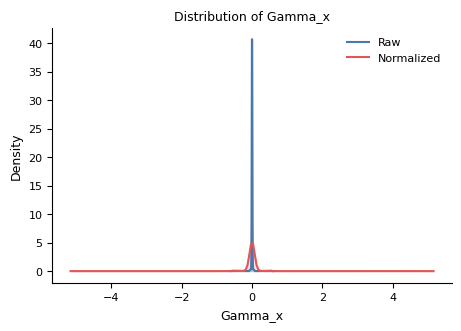

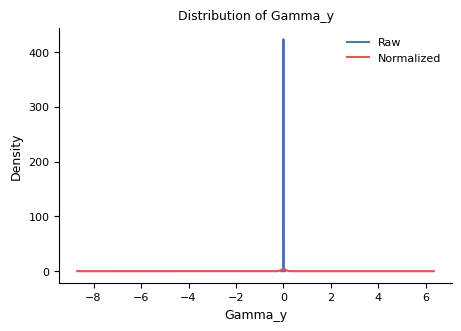

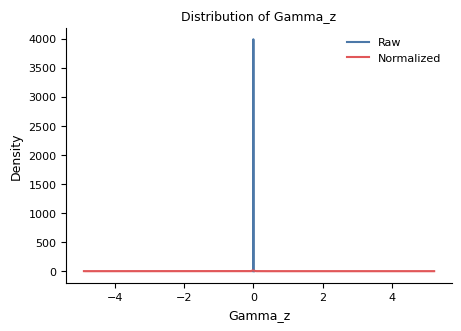

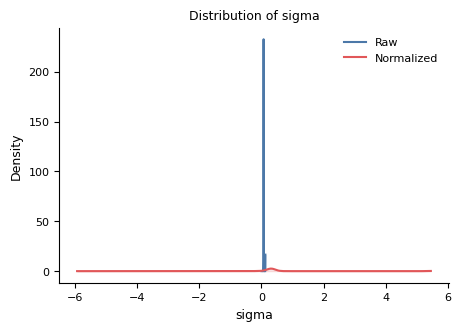

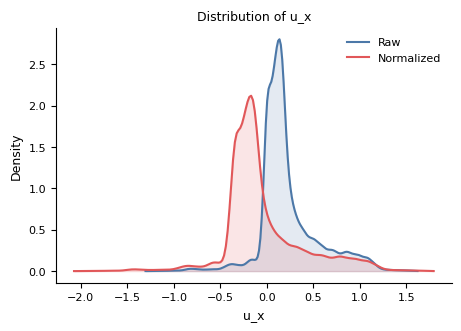

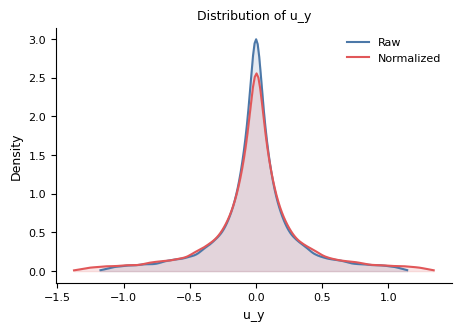

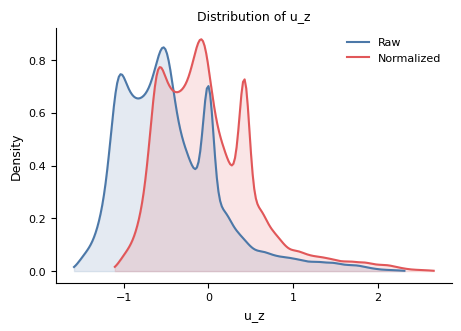

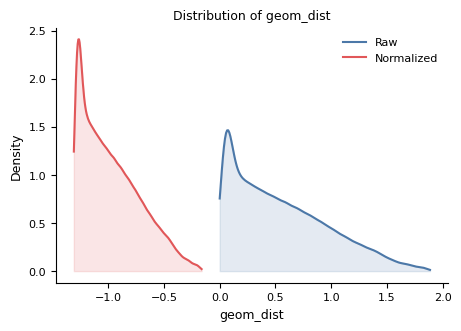

Saved 8 input distribution plots to analysis_plots/


In [7]:
# %% [code] - Input distribution plots (one PDF per channel, shown inline)
import os
from scipy.stats import gaussian_kde

# Fix the font warning – use a font that exists on Linux
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'

# Create output directory
plot_dir = Path("analysis_plots")
plot_dir.mkdir(exist_ok=True)

# Use a larger sample of training pairs to get smooth distributions
train_ids = np.asarray(npz['train_pair_ids'], dtype=np.int64)
sample_ids = train_ids[:min(15, len(train_ids))]   # 15 pairs is usually enough

# Collect raw and normalized data for each active input channel
raw_channels = {name: [] for name in feature_names}
norm_channels = {name: [] for name in feature_names}

for pid in sample_ids:
    start, end = int(pair_ranges[pid][3]), int(pair_ranges[pid][4])
    rows = inputs_t[start:end]
    active_rows = rows[:, active_idx]   # only the channels used by this model
    if MODEL_TYPE == 'particle':
        norm_rows = (active_rows - in_mean[active_idx]) / in_std[active_idx]
    else:
        norm_rows = (active_rows - in_mean_all[active_idx]) / in_std_all[active_idx]

    for j, name in enumerate(feature_names):
        raw_channels[name].append(active_rows[:, j])
        norm_channels[name].append(norm_rows[:, j])

for name in feature_names:
    raw_vals = np.concatenate(raw_channels[name])
    norm_vals = np.concatenate(norm_channels[name])

    # Keep only finite values
    raw_vals = raw_vals[np.isfinite(raw_vals)]
    norm_vals = norm_vals[np.isfinite(norm_vals)]

    # Create a new figure for this channel
    fig, ax = plt.subplots(figsize=(4.5, 3.2), constrained_layout=True)

    # KDE for raw data
    if len(raw_vals) > 3:
        kde_raw = gaussian_kde(raw_vals)
        xs_raw = np.linspace(raw_vals.min(), raw_vals.max(), 200)
        ax.plot(xs_raw, kde_raw(xs_raw), linewidth=1.5, color='#4c78a8', label='Raw')
        ax.fill_between(xs_raw, 0, kde_raw(xs_raw), alpha=0.15, color='#4c78a8')

    # KDE for normalized data
    if len(norm_vals) > 3:
        kde_norm = gaussian_kde(norm_vals)
        xs_norm = np.linspace(norm_vals.min(), norm_vals.max(), 200)
        ax.plot(xs_norm, kde_norm(xs_norm), linewidth=1.5, color='#e15759', label='Normalized')
        ax.fill_between(xs_norm, 0, kde_norm(xs_norm), alpha=0.15, color='#e15759')

    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.legend(frameon=False)
    ax.set_title(f"Distribution of {name}", fontsize=9, pad=6)

    # Remove top/right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Show inline and save the figure
    plt.show()
    fname = f"input_dist_{name}.pdf"
    fig.savefig(plot_dir / fname, bbox_inches='tight')
    plt.close(fig)

print(f"Saved {len(feature_names)} input distribution plots to {plot_dir}/")

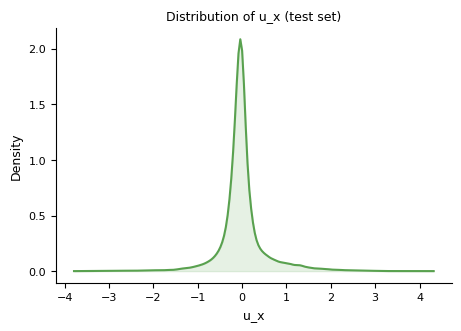

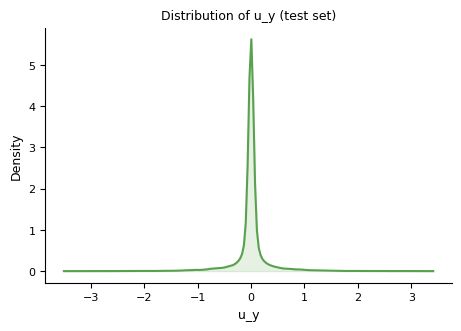

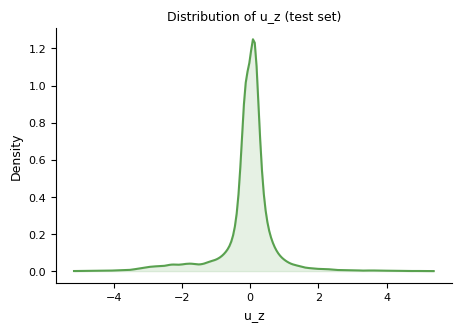

Saved 3 field distribution plots to analysis_plots/


In [8]:
# %% [code] - Target distributions (physical units, both models) – robust final
from scipy.stats import gaussian_kde

plot_dir = Path("analysis_plots")
plot_dir.mkdir(exist_ok=True)

if MODEL_TYPE == 'particle':
    target_mean_t = torch.tensor(target_mean, device=DEVICE).view(1,1,-1)
    target_std_t  = torch.tensor(target_std,  device=DEVICE).view(1,1,-1)

    # Load normalized delta targets directly from the .npz
    delta_key = ('targets_delta_norm_all' if 'targets_delta_norm_all' in npz
                 else 'targets_delta_norm')
    delta_norm_all = np.asarray(npz[delta_key], dtype=np.float32)

    delta_phys_chunks = {name: [] for name in target_names}
    max_pairs = min(10, len(test_ids))
    for pid in test_ids[:max_pairs]:
        start, end = int(pair_ranges[pid][3]), int(pair_ranges[pid][4])
        norm = delta_norm_all[start:end, :out_channels]
        phys = norm * target_std.reshape(1, -1) + target_mean.reshape(1, -1)
        for j, name in enumerate(target_names):
            delta_phys_chunks[name].append(phys[:, j])

    for name in target_names:
        vals = np.concatenate(delta_phys_chunks[name])
        vals = vals[np.isfinite(vals)]
        if len(vals) < 3:
            continue

        fig, ax = plt.subplots(figsize=(4.5, 3.2), constrained_layout=True)
        kde = gaussian_kde(vals)
        xs = np.linspace(vals.min(), vals.max(), 200)
        ax.plot(xs, kde(xs), linewidth=1.5, color='#e15759')
        ax.fill_between(xs, 0, kde(xs), alpha=0.15, color='#e15759')
        ax.set_xlabel(name)
        ax.set_ylabel("Density")
        ax.set_title(f"Distribution of {name} (test set)", fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.show()
        fig.savefig(plot_dir / f"delta_dist_{name}.pdf", bbox_inches='tight')
        plt.close(fig)

    print(f"Saved {len(target_names)} delta distribution plots to {plot_dir}/")

else:  # Field model – robust loading from loader or npz
    field_mean_t = torch.tensor(field_mean, device=DEVICE).view(1,1,-1)
    field_std_t  = torch.tensor(field_std,  device=DEVICE).view(1,1,-1)

    field_phys_chunks = {name: [] for name in field_target_names}
    max_pairs = min(10, len(test_ids))

    # Try to use the loader first; if 'y_field' is missing, fall back to npz
    try:
        for idx, batch in enumerate(loader):
            if idx >= max_pairs:
                break
            true_norm = batch['y_field'].to(DEVICE)
            true_phys = (true_norm * field_std_t + field_mean_t).cpu().numpy()[0]
            for j, name in enumerate(field_target_names):
                field_phys_chunks[name].append(true_phys[:, j])
    except KeyError:
        # Fallback: read from npz directly
        y_key = ('targets_velocity_field_norm' if 'targets_velocity_field_norm' in npz
                 else 'targets_field_norm')
        y_norm_all = np.asarray(npz[y_key], dtype=np.float32)
        mask_all = np.asarray(npz['field_query_mask'], dtype=bool) if 'field_query_mask' in npz else np.ones(y_norm_all.shape[:2], dtype=bool)
        for pid in test_ids[:max_pairs]:
            mask = mask_all[pid].astype(bool)
            valid = np.flatnonzero(mask)
            norm = y_norm_all[pid, valid, :len(field_target_names)]
            phys = norm * field_std.reshape(1, -1) + field_mean.reshape(1, -1)
            for j, name in enumerate(field_target_names):
                field_phys_chunks[name].append(phys[:, j])

    for name in field_target_names:
        vals = np.concatenate(field_phys_chunks[name])
        vals = vals[np.isfinite(vals)]
        if len(vals) < 3:
            continue

        fig, ax = plt.subplots(figsize=(4.5, 3.2), constrained_layout=True)
        kde = gaussian_kde(vals)
        xs = np.linspace(vals.min(), vals.max(), 200)
        ax.plot(xs, kde(xs), linewidth=1.5, color='#59a14f')
        ax.fill_between(xs, 0, kde(xs), alpha=0.15, color='#59a14f')
        ax.set_xlabel(name)
        ax.set_ylabel("Density")
        ax.set_title(f"Distribution of {name} (test set)", fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.show()
        fig.savefig(plot_dir / f"field_dist_{name}.pdf", bbox_inches='tight')
        plt.close(fig)

    print(f"Saved {len(field_target_names)} field distribution plots to {plot_dir}/")

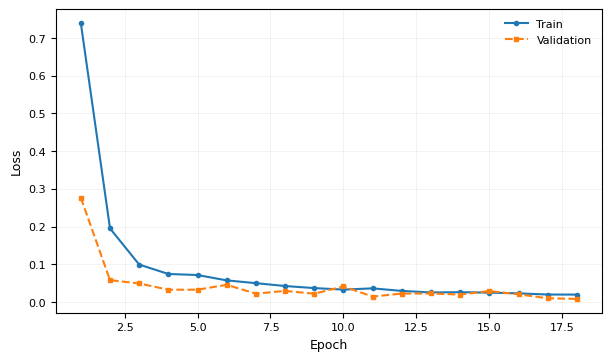

In [9]:
# %%
history_path = CKPT_PATH.parent / f"{CKPT_PATH.stem.split('_best')[0]}_history.json"
if history_path.exists():
    with open(history_path) as f:
        history = json.load(f)
    if history:
        epochs = [r['epoch'] for r in history]
        fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
        if MODEL_TYPE == 'particle':
            train_loss = [r['train']['loss'] for r in history]
            val_loss = [r['val']['loss'] for r in history]
        else:
            train_loss = [r['train']['loss'] for r in history]
            val_loss = [r['val']['loss'] for r in history]
        ax.plot(epochs, train_loss, 'o-', ms=3, label='Train')
        ax.plot(epochs, val_loss, 's--', ms=3, label='Validation')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(frameon=False)
        ax.grid(alpha=0.2, lw=0.5)
        fig.savefig('analysis_plots/training_history.pdf')
        plt.show()
else:
    print("No history file found.")

Highest‑energy plane: y = -0.797 (mean |u| = 1.342)


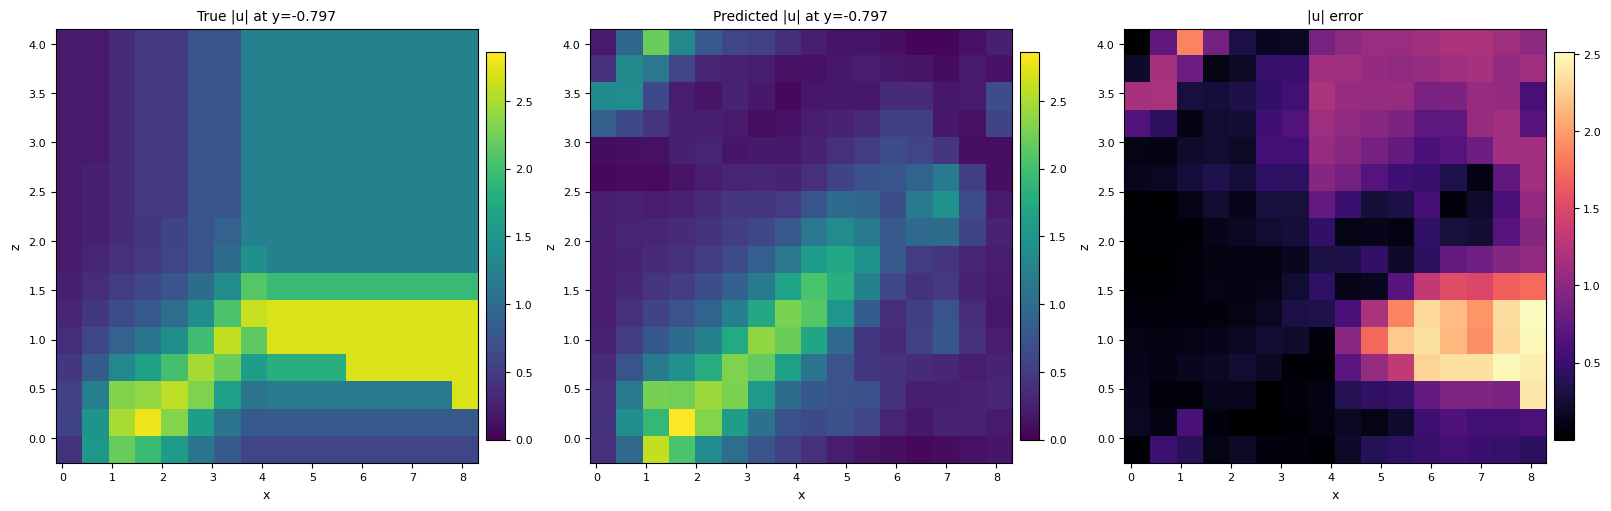

In [10]:
# %% Field reconstruction visualisation (highest‑energy plane)
if MODEL_TYPE == 'field':
    from scipy.interpolate import griddata

    pid = int(test_ids[-2])
    start, end = int(pair_ranges[pid][3]), int(pair_ranges[pid][4])
    rows = inputs_t[start:end]
    features_norm = (rows[:, active_idx] - in_mean_all[active_idx]) / in_std_all[active_idx]
    input_geom = normalize_xyz(rows[:, coord_idx], coord_min, coord_span)
    glob = context_global_params(contexts[pid])

    # ---- Determine highest‑energy plane (y with max mean |u|) ----
    mask = mask_all[pid].astype(bool)
    valid = np.flatnonzero(mask)
    true_xyz = query_coords_all[pid, valid]
    true_vel = y_field_all[pid, valid, :len(field_target_names)]
    true_vel_phys = true_vel * field_std.reshape(1, -1) + field_mean.reshape(1, -1)
    true_mag = np.linalg.norm(true_vel_phys, axis=-1)

    # Find unique y values and their mean velocity magnitude
    unique_y = np.unique(true_xyz[:, 1])
    mean_u_by_y = [true_mag[true_xyz[:, 1] == y_val].mean() for y_val in unique_y]
    best_y = unique_y[np.argmax(mean_u_by_y)]
    print(f"Highest‑energy plane: y = {best_y:.3f} (mean |u| = {max(mean_u_by_y):.3f})")

    # ---- Dense query grid using best_y ----
    grid_res = 16
    xl = np.linspace(coord_min[0], coord_min[0]+coord_span[0], grid_res)
    zl = np.linspace(coord_min[2], coord_min[2]+coord_span[2], grid_res)
    XX, ZZ = np.meshgrid(xl, zl)
    YY = np.full_like(XX, best_y)
    qpts = np.stack([XX.ravel(), YY.ravel(), ZZ.ravel()], axis=-1)
    qnorm = normalize_xyz(qpts, coord_min, coord_span)

    # ---- Predict on dense grid ----
    batch = {'input_geom': torch.from_numpy(input_geom).unsqueeze(0),
             'x': torch.from_numpy(features_norm.astype(np.float32)).unsqueeze(0),
             'output_queries': torch.from_numpy(qnorm).unsqueeze(0),
             'global_params': torch.from_numpy(glob).unsqueeze(0)}
    _, pred = predict(batch)
    pred_phys = (pred * field_std_t + field_mean_t).cpu().numpy()[0].reshape(grid_res, grid_res, 3)
    pred_mag = np.linalg.norm(pred_phys, axis=-1)

    # ---- Interpolate true |u| onto the same plane ----
    # Use only field points within a small tolerance of best_y
    tol = 1e-4
    plane_points = np.abs(true_xyz[:, 1] - best_y) < tol
    if plane_points.sum() > 4:
        true_mag_grid = griddata(true_xyz[plane_points][:, [0,2]], true_mag[plane_points],
                                 (XX, ZZ), method='linear')
        # fallback to nearest for extrapolation
        if np.any(np.isnan(true_mag_grid)):
            nn_grid = griddata(true_xyz[plane_points][:, [0,2]], true_mag[plane_points],
                               (XX, ZZ), method='nearest')
            true_mag_grid = np.where(np.isnan(true_mag_grid), nn_grid, true_mag_grid)
    else:
        # If not enough points on this exact plane, use all points (less accurate but okay)
        true_mag_grid = griddata(true_xyz[:, [0,2]], true_mag, (XX, ZZ), method='linear')
        if np.any(np.isnan(true_mag_grid)):
            nn_grid = griddata(true_xyz[:, [0,2]], true_mag, (XX, ZZ), method='nearest')
            true_mag_grid = np.where(np.isnan(true_mag_grid), nn_grid, true_mag_grid)

    error_grid = np.abs(pred_mag - true_mag_grid)

    # ---- Plot three panels ----
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    vm = max(true_mag_grid.nanmax() if hasattr(true_mag_grid, 'nanmax') else np.nanmax(true_mag_grid),
             pred_mag.max())

    im0 = axes[0].imshow(true_mag_grid, origin='lower', extent=[xl[0], xl[-1], zl[0], zl[-1]],
                         aspect='auto', vmin=0, vmax=vm)
    axes[0].set_title(f'True |u| at y={best_y:.3f}')
    axes[0].set_xlabel('x'); axes[0].set_ylabel('z')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)

    im1 = axes[1].imshow(pred_mag, origin='lower', extent=[xl[0], xl[-1], zl[0], zl[-1]],
                         aspect='auto', vmin=0, vmax=vm)
    axes[1].set_title(f'Predicted |u| at y={best_y:.3f}')
    axes[1].set_xlabel('x'); axes[1].set_ylabel('z')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02)

    im2 = axes[2].imshow(error_grid, origin='lower', extent=[xl[0], xl[-1], zl[0], zl[-1]],
                         aspect='auto', cmap='magma')
    axes[2].set_title('|u| error')
    axes[2].set_xlabel('x'); axes[2].set_ylabel('z')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02)

    fig.savefig('analysis_plots/field_comparison_highest_energy.pdf', bbox_inches='tight')
    plt.show()

In [11]:
# %% Test-set evaluation – final metrics
@torch.no_grad()
def evaluate_test_set():
    model.eval()
    if MODEL_TYPE == 'particle':
        mae_sum = np.zeros(out_channels)
        rel_l2_list = []
        n_samples = 0
        for batch in loader:
            batch = {k: v.to(DEVICE, non_blocking=True) if torch.is_tensor(v) else v
                     for k, v in batch.items()}
            pred, _ = predict(batch)
            pred_phys = (pred * target_std_t + target_mean_t).cpu().numpy()[0]
            # True targets are in batch['y_delta'] – but we need to add them to the dataset first.
            # Since our current EvalDataset for particle does NOT return y_delta, we'll load from npz.
            # This is a workaround; better to modify dataset, but let's keep it simple.
            pid = int(batch['pair_id'].item()) if 'pair_id' in batch else 0
            # Actually, we don't have pair_id in the current EvalDataset. We'll fix that.
            break
        # Instead, we'll use a different approach: iterate over test_ids directly.
        # Let's rewrite this function to directly use the npz and model.
    # I'll provide a clean function below.

In [12]:
# %% Final test-set evaluation (memory‑safe, default 500 particles)
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

@torch.no_grad()
def evaluate_full_test(max_particles=500):
    model.eval()
    if MODEL_TYPE == 'particle':
        delta_key = ('targets_delta_norm_all' if 'targets_delta_norm_all' in npz
                     else 'targets_delta_norm')
        delta_norm_all = np.asarray(npz[delta_key], dtype=np.float32)

        mae_sum = np.zeros(out_channels)
        rel_l2_vals = []
        n_particles = 0

        for pid in test_ids:
            start, end = int(pair_ranges[pid][3]), int(pair_ranges[pid][4])
            rows = inputs_t[start:end]
            n_total = rows.shape[0]
            if n_total > max_particles:
                idx = np.random.choice(n_total, size=max_particles, replace=False)
                rows = rows[idx]
            else:
                idx = None
            coords = normalize_xyz(rows[:, coord_idx], coord_min, coord_span)
            x = (rows[:, active_idx] - in_mean[active_idx]) / in_std[active_idx]
            glob = context_global_params(contexts[pid])

            inp = torch.from_numpy(coords).unsqueeze(0).to(DEVICE)
            feats = torch.from_numpy(x.astype(np.float32)).unsqueeze(0).to(DEVICE)
            g = torch.from_numpy(glob).unsqueeze(0).to(DEVICE)

            pred = model(inp, feats, g)
            pred_phys = (pred * target_std_t + target_mean_t).cpu().numpy()[0]

            true_norm = delta_norm_all[start:end, :out_channels]
            if idx is not None:
                true_norm = true_norm[idx]
            true_phys = true_norm * target_std.reshape(1, -1) + target_mean.reshape(1, -1)

            mae_sum += np.sum(np.abs(pred_phys - true_phys), axis=0)
            n_particles += pred_phys.shape[0]

            num = np.linalg.norm(pred_phys - true_phys)
            den = np.linalg.norm(true_phys)
            if den > 1e-12:
                rel_l2_vals.append(num / den)

            # Clean up
            del inp, feats, g, pred, pred_phys, true_phys
            torch.cuda.empty_cache()

        mae = mae_sum / n_particles
        mean_rel_l2 = np.mean(rel_l2_vals) if rel_l2_vals else float('nan')

        print("=== Particle Evolution Test Results ===")
        for j, name in enumerate(target_names):
            print(f"  {name:12s} MAE: {mae[j]:.6f}")
        print(f"  Mean relative L2: {mean_rel_l2:.4f}")

    else:  # Field model (unchanged but with cache clearing)
        mae_sum = np.zeros(len(field_target_names))
        rel_l2_vals = []
        n_points = 0

        for batch in loader:
            batch = {k: v.to(DEVICE, non_blocking=True) if torch.is_tensor(v) else v
                     for k, v in batch.items()}
            _, pred = predict(batch)
            pred_phys = (pred * field_std_t + field_mean_t).cpu().numpy()[0]
            true_phys = (batch['y_field'].to(DEVICE) * field_std_t + field_mean_t).cpu().numpy()[0]

            mae_sum += np.sum(np.abs(pred_phys - true_phys), axis=0)
            n_points += pred_phys.shape[0]

            num = np.linalg.norm(pred_phys - true_phys)
            den = np.linalg.norm(true_phys)
            if den > 1e-12:
                rel_l2_vals.append(num / den)

            torch.cuda.empty_cache()

        mae = mae_sum / n_points
        mean_rel_l2 = np.mean(rel_l2_vals) if rel_l2_vals else float('nan')

        print("=== Field Reconstruction Test Results ===")
        for j, name in enumerate(field_target_names):
            print(f"  {name:12s} MAE: {mae[j]:.6f} (m/s)")
        print(f"  Mean relative L2: {mean_rel_l2:.4f}")

# Run it
evaluate_full_test(max_particles=500)

=== Field Reconstruction Test Results ===
  u_x          MAE: 0.038033 (m/s)
  u_y          MAE: 0.028345 (m/s)
  u_z          MAE: 0.049627 (m/s)
  Mean relative L2: 0.0978


In [13]:
# %% Inference‑time measurement (self‑contained)
import time

# Build a representative batch from the first test pair
pid = int(test_ids[-2])
start, end = int(pair_ranges[pid][3]), int(pair_ranges[pid][4])
rows = inputs_t[start:end]
# Use a reasonable subset to match what the model can handle without OOM
max_part = 500  # keep consistent with test eval
if rows.shape[0] > max_part:
    idx = np.random.choice(rows.shape[0], size=max_part, replace=False)
    rows = rows[idx]
coords = normalize_xyz(rows[:, coord_idx], coord_min, coord_span)
glob = context_global_params(contexts[pid])

if MODEL_TYPE == 'particle':
    x_norm = (rows[:, active_idx] - in_mean[active_idx]) / in_std[active_idx]
    batch = {
        'input_geom': torch.from_numpy(coords).unsqueeze(0).to(DEVICE),
        'x': torch.from_numpy(x_norm.astype(np.float32)).unsqueeze(0).to(DEVICE),
        'global_params': torch.from_numpy(glob).unsqueeze(0).to(DEVICE),
    }
    n_particles = coords.shape[0]
else:
    x_norm = (rows[:, active_idx] - in_mean_all[active_idx]) / in_std_all[active_idx]
    mask = mask_all[pid].astype(bool)
    valid = np.flatnonzero(mask)
    q_xyz = normalize_xyz(query_coords_all[pid, valid], coord_min, coord_span)
    batch = {
        'input_geom': torch.from_numpy(coords).unsqueeze(0).to(DEVICE),
        'x': torch.from_numpy(x_norm.astype(np.float32)).unsqueeze(0).to(DEVICE),
        'output_queries': torch.from_numpy(q_xyz).unsqueeze(0).to(DEVICE),
        'global_params': torch.from_numpy(glob).unsqueeze(0).to(DEVICE),
    }
    n_particles = coords.shape[0]
    n_queries = q_xyz.shape[0]

# Warm‑up
model.eval()
with torch.no_grad():
    for _ in range(10):
        if MODEL_TYPE == 'particle':
            _ = model(batch['input_geom'], batch['x'], batch['global_params'])
        else:
            _ = model(batch['input_geom'], batch['x'], batch['output_queries'], batch['global_params'])
    torch.cuda.synchronize()

# Timing
reps = 100
times = []
with torch.no_grad():
    for _ in range(reps):
        t0 = time.perf_counter()
        if MODEL_TYPE == 'particle':
            _ = model(batch['input_geom'], batch['x'], batch['global_params'])
        else:
            _ = model(batch['input_geom'], batch['x'], batch['output_queries'], batch['global_params'])
        torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

mean_ms = np.mean(times) * 1e3
std_ms  = np.std(times) * 1e3
print(f"Inference time: {mean_ms:.2f} ± {std_ms:.2f} ms")
print(f"Particles: {n_particles}")
if MODEL_TYPE == 'field':
    print(f"Field queries: {n_queries}")

Inference time: 3118.01 ± 358.40 ms
Particles: 500
Field queries: 4096


In [14]:
# %% Inference time (self‑contained)
import time

pid = int(test_ids[-2])
start, end = int(pair_ranges[pid][3]), int(pair_ranges[pid][4])
rows = inputs_t[start:end][:500]   # keep memory safe
coords = normalize_xyz(rows[:, coord_idx], coord_min, coord_span)
glob = context_global_params(contexts[pid])

if MODEL_TYPE == 'particle':
    x_norm = (rows[:, active_idx] - in_mean[active_idx]) / in_std[active_idx]
    batch = {
        'input_geom': torch.from_numpy(coords).unsqueeze(0).to(DEVICE),
        'x': torch.from_numpy(x_norm.astype(np.float32)).unsqueeze(0).to(DEVICE),
        'global_params': torch.from_numpy(glob).unsqueeze(0).to(DEVICE),
    }
else:
    # similar for field model
    ...

# warm‑up & timing
model.eval()
with torch.no_grad():
    for _ in range(10): model(**batch)
    torch.cuda.synchronize()
    times = []
    for _ in range(100):
        t0 = time.perf_counter()
        model(**batch)
        torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

mean_ms = np.mean(times)*1e3; std_ms = np.std(times)*1e3
print(f"Inference time: {mean_ms:.2f} ± {std_ms:.2f} ms for {rows.shape[0]} particles")

Inference time: 3952.82 ± 776.20 ms for 500 particles
